In [1]:
import os

# change directory one up 
os.chdir('..')


In [33]:
import importlib
import utils
importlib.reload(utils)
from notebooks.utils import *

In [69]:
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'
prefix_bias_param_shift = 'bias_param_shift_'
prefix_relevance_param_shift = 'predicted_relevance_param_shift_'

# now these represent s_doc values
s_doc_values = [0.3, -0.3, 10]
policy_temperatures = [0.0, 1.0]
doc_group_sizes = [10, 100, 25, 500]
relevance_towers = ['deeper']

def make_folder_path(n_queries, s_doc, policy_temperature, relevance_tower):
    return (
        f"results/Synthetic_Feature_Separation_4/"
        f"data=Custom_dataset_deep,docs_per_group=10,experiment=Synthetic_Feature_Separation_4,"
        f"logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,"
        f"num_queries={n_queries},policy_temperature={policy_temperature},"
        f"relevance=deep,relevance_tower={relevance_tower},s_doc={s_doc}"
    )

# Initialize final collectors
all_multi_performance_df = []
all_multi_relevance_df = []
all_multi_bias_df = []
all_multi_predicted_relevance_df = []

for s_doc in s_doc_values:
    for policy_temp in policy_temperatures:
        for n_queries in doc_group_sizes:
            for relevance_tower in relevance_towers:
                folder_path = make_folder_path(n_queries, s_doc, policy_temp, relevance_tower)
                print(f"📂 Loading data from: {folder_path}")

                # Load all types of data
                try:
                    perf_df = load_and_concat_multi_shift_files(folder_path, prefix_performance_clicks, 'relevance_shift', 'param_idx')
                    rel_df = load_and_concat_multi_shift_files(folder_path, prefix_performance_relevance, 'relevance_shift', 'param_idx')
                    # bias_df = load_and_concat_multi_shift_files(folder_path, prefix_bias_param_shift, 'relevance_shift', 'param_idx')

                    # Annotate metadata
                    for df in [perf_df, rel_df]:
                        df['s_doc'] = s_doc
                        df['policy_temperature'] = policy_temp
                        df['n_queries'] = n_queries
                        df['relevance_tower'] = relevance_tower

                    # Append to master lists
                    all_multi_performance_df.append(perf_df)
                    all_multi_relevance_df.append(rel_df)
                    # all_multi_bias_df.append(bias_df)
                    print(f"✅ Loaded data for s_doc={s_doc}, temp={policy_temp}, n_queries={n_queries}, tower={relevance_tower}")
                except Exception as e:
                    print(f"⚠️  Failed to load data for s_doc={s_doc}, temp={policy_temp}, n_queries={n_queries}, tower={relevance_tower}: {e}")
                    pass
                try:
                    pred_rel_df = pd.read_csv(f"{folder_path}/predicted_relevance.csv")
                    for df in [pred_rel_df]:
                        df['s_doc'] = s_doc
                        df['policy_temperature'] = policy_temp
                        df['n_queries'] = n_queries
                        df['relevance_tower'] = relevance_tower
                    all_multi_predicted_relevance_df.append(pred_rel_df)
                except Exception as e:
                    pass


# ✅ Concatenate everything into single DataFrames
all_multi_performance_df = pd.concat(all_multi_performance_df, ignore_index=True)
# all_multi_relevance_df = pd.concat(all_multi_relevance_df, ignore_index=True)
# all_multi_bias_df = pd.concat(all_multi_bias_df, ignore_index=True)
# all_multi_predicted_relevance_df = pd.concat(all_multi_predicted_relevance_df, ignore_index=True)
all_multi_performance_df = all_multi_performance_df[all_multi_performance_df.relevance_shift < 4]
all_multi_performance_df = all_multi_performance_df[all_multi_performance_df.relevance_shift > -4]
print("✅ Aggregated data shapes:")
print("Performance:", all_multi_performance_df.shape)
# print("Relevance:", all_multi_relevance_df.shape)
# print("Bias:", all_multi_bias_df.shape)
# print("Predicted Relevance:", all_multi_predicted_relevance_df.shape)


📂 Loading data from: results/Synthetic_Feature_Separation_4/data=Custom_dataset_deep,docs_per_group=10,experiment=Synthetic_Feature_Separation_4,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,num_queries=10,policy_temperature=0.0,relevance=deep,relevance_tower=deeper,s_doc=0.3
['test_clicks_param_shift_-1_idx0.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_3_idx0.csv', 'test_clicks_param_shift_2_idx0.csv', 'test_clicks_param_shift_-3_idx0.csv', 'test_clicks_param_shift_-2_idx0.csv', 'test_clicks_param_shift_1_idx0.csv']
['test_relevance_param_shift_-1_idx0.csv', 'test_relevance_param_shift_3_idx0.csv', 'test_relevance_param_shift_2_idx0.csv', 'test_relevance_param_shift_0.0_idx0.csv', 'test_relevance_param_shift_-3_idx0.csv', 'test_relevance_param_shift_-2_idx0.csv', 'test_relevance_param_shift_1_idx0.csv']
✅ Loaded data for s_doc=0.3, temp=0.0, n_queries=10, tower=deeper
📂 Loading data from: results/Synthetic_Feature_Separation_4/data=Custom_data

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec


# ---------------------------------------------------------------------
# Deep Relevance model and helpers
# ---------------------------------------------------------------------
class DeepRelevance:
    def __init__(self, hidden_units=[32, 32, 32], *, random_state: int, noise: float = 0.0):
        self.hidden_units = hidden_units
        self.noise = noise
        self.rng = np.random.default_rng(random_state)
        self.layers = []

    def __call__(self, query_document_features: np.ndarray) -> np.ndarray:
        n_docs, n_features = query_document_features.shape
        if not self.layers:
            input_size = n_features
            for units in self.hidden_units:
                W = self.rng.standard_normal((input_size, units))
                b = self.rng.standard_normal(units)
                self.layers.append((W, b))
                input_size = units
            W_out = self.rng.standard_normal(input_size)
            b_out = self.rng.standard_normal()
            self.output_layer = (W_out, b_out)

        hidden = query_document_features
        for (W, b) in self.layers:
            hidden = np.tanh(hidden.dot(W) + b)
        scores = hidden.dot(self.output_layer[0]) + self.output_layer[1]
        noise = self.noise * self.rng.standard_normal(scores.shape)
        return scores + noise


def generate_deep_score_and_features_overlap(num_queries, docs_per_group, s_doc, rng, deep_model):
    all_scores, all_data, boundaries = [], [], []

    for qid in range(num_queries):
        begin, end = 0.0, 1.0
        q_boundaries = []

        for doc_idx in range(docs_per_group):
            a = 0.0
            if doc_idx == 0:
                b = rng.uniform(begin, end + s_doc)
                q_boundaries.append((begin, end + s_doc, doc_idx))
            elif doc_idx == docs_per_group - 1:
                b = rng.uniform(begin - s_doc, end)
                q_boundaries.append((begin - s_doc, end, doc_idx))
            else:
                b = rng.uniform(begin - s_doc, end + s_doc)
                q_boundaries.append((begin - s_doc, end + s_doc, doc_idx))

            features = np.array([[a, b]])
            score = deep_model(features)[0]
            all_scores.append(score)
            all_data.append((qid, doc_idx, [a, b]))

            begin += 1
            end += 1

        boundaries.append(q_boundaries)

    return np.array(all_scores), np.array(all_data, dtype=object), boundaries


def visualize_deep_relevance_with_caps(
    num_queries=2,
    docs_per_group=10,
    s_doc=0.0,
    hidden_units=[32, 32, 32],
    noise=0.0,
    random_state=41,
    show_boundaries=True,
    show_fill=True,
    fill_cmap="tab10",
    point_cmap="tab10",
    seed=42,
    jitter=0.0,
    baseline_gap=0.1,
    cap_height=0.03,
    ax=None,
    figsize=(10, 6),
):
    rng = np.random.default_rng(seed)
    deep_relevance = DeepRelevance(hidden_units=hidden_units, random_state=random_state, noise=noise)

    scores, data, boundaries = generate_deep_score_and_features_overlap(
        num_queries=num_queries,
        docs_per_group=docs_per_group,
        s_doc=s_doc,
        rng=rng,
        deep_model=deep_relevance,
    )

    doc_ids = np.array([d[1] for d in data])
    b_values = np.array([d[2][1] for d in data])

    # Model curve
    a_plot = np.zeros_like(np.linspace(0, 10, 500))
    b_plot = np.linspace(0, 10, 500)
    X_plot = np.column_stack((a_plot, b_plot))
    y_plot = np.ravel(deep_relevance(X_plot))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        created_fig = False

    cmap_fill = plt.get_cmap(fill_cmap)
    cmap_point = plt.get_cmap(point_cmap)
    fill_colors = [cmap_fill(i / max(1, docs_per_group - 1)) for i in range(docs_per_group)]
    point_colors = [cmap_point(i / max(1, docs_per_group - 1)) for i in range(docs_per_group)]

    mean_bounds = []
    for doc_idx in range(docs_per_group):
        lefts = [q_bounds[doc_idx][0] for q_bounds in boundaries]
        rights = [q_bounds[doc_idx][1] for q_bounds in boundaries]
        mean_bounds.append((np.mean(lefts), np.mean(rights)))

    # Fill + boundary lines
    if show_fill:
        for i, (left, right) in enumerate(mean_bounds):
            color = fill_colors[i % len(fill_colors)]
            ax.axvspan(left, right, color=color, alpha=0.25)
            baseline_y = -baseline_gap * i - 1
            shift = 0.05
            ax.hlines(y=baseline_y, xmin=left + shift, xmax=right - shift, color=color, lw=3, alpha=0.9)
            ax.vlines([left + shift, right - shift], baseline_y - cap_height, baseline_y + cap_height, color=color, lw=2)

    if show_boundaries:
        for i, (left, right) in enumerate(mean_bounds):
            color = fill_colors[i % len(fill_colors)]
            ax.axvline(x=left, color=color, ls='--', lw=1.3, alpha=0.8)
            ax.axvline(x=right, color=color, ls='--', lw=1.3, alpha=0.8)

    # Points Randomized drawing order
    handles, labels = [], []
    unique_doc_ids = np.unique(doc_ids)

    # Compute jittered scores
    y_vals_all = scores + rng.normal(0, jitter, size=scores.shape)

    # Collect all data in one array
    all_points = np.column_stack((b_values, y_vals_all, doc_ids))

    # Randomize draw order (vectorized shuffle)
    rng.shuffle(all_points)

    # Extract shuffled columns
    x_shuffled = all_points[:, 0]
    y_shuffled = all_points[:, 1]
    doc_shuffled = all_points[:, 2].astype(int)

    # Map colors efficiently
    colors = np.array([point_colors[i % len(point_colors)] for i in doc_shuffled])

    # Draw all points in one fast call
    ax.scatter(
        x_shuffled,
        y_shuffled,
        c=colors,
        s=90,
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

    # Create legend entries once per rank
    for doc_idx in unique_doc_ids:
        color = point_colors[doc_idx % len(point_colors)]
        sc = ax.scatter([], [], color=color, s=90, edgecolor='black', linewidth=0.8, label=f"Rank {doc_idx}")
        handles.append(sc)
        labels.append(f"Rank {doc_idx}")

    line, = ax.plot(b_plot, y_plot, color='black', lw=2, label='Deep relevance curve')
    handles.append(line)
    labels.append('Deep relevance curve')

    ax.set_xlabel('Feature b')
    ax.set_ylabel('Score')
    ax.set_xlim(0, 10)
    ax.grid(alpha=0.3)

    ymin = min(-baseline_gap * docs_per_group, np.min(y_plot) - 0.2)
    ymax = np.max(y_plot) + 0.2
    ax.set_ylim(ymin - 1, ymax)

    ax.legend(handles, labels, fontsize=7, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=min(6, len(labels)))
    if created_fig:
        plt.tight_layout()
        plt.show()

    return ax


# ---------------------------------------------------------------------
# Performance + Relevance combined visualization
# ---------------------------------------------------------------------
def plot_performance_row_with_relevance(
    df,
    s_doc,
    metric='loss',
    diff_from_zero=False,
    visualize_fn=None,
    num_queries_for_sdoc=10,
    relevance_tower='deep'
):
    if visualize_fn is None:
        visualize_fn = visualize_deep_relevance_with_caps
    df = df[df['relevance_tower'] == relevance_tower]
    required_cols = {'relevance_shift', 'param_idx', 's_doc', 'policy_temperature', 'n_queries', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Missing columns: {required_cols - set(df.columns)}")

    temperatures = sorted(df['policy_temperature'].unique())
    n_queries_list = sorted(df['n_queries'].unique())
    n_cols = len(temperatures)

    fig = plt.figure(figsize=(6 * (n_cols + 1.1), 4.5))
    gs = gridspec.GridSpec(1, n_cols + 1, width_ratios=[1]*n_cols + [1.7], wspace=0.15, figure=fig)

    left_axes, all_y_values = [], []
    left_legend_handles, left_legend_labels = None, None

    first_ax = None
    for j, temp in enumerate(temperatures):
        ax = fig.add_subplot(gs[0, j], sharey=first_ax) if first_ax else fig.add_subplot(gs[0, j])
        if first_ax is None:
            first_ax = ax
        left_axes.append(ax)

        subset = df[(df['s_doc'] == s_doc) & (df['policy_temperature'] == temp)]
        if subset.empty:
            ax.axis("off")
            continue

        for n_q in n_queries_list:
            sub_q = subset[subset["n_queries"] == n_q].sort_values("relevance_shift")
            if sub_q.empty:
                continue

            if diff_from_zero:
                baseline_vals = sub_q.loc[sub_q["relevance_shift"] == 0, metric]
                baseline = baseline_vals.mean() if not baseline_vals.empty else sub_q.iloc[(sub_q["relevance_shift"] - 0).abs().idxmin()][metric]
                y_values = sub_q[metric] - baseline
                label = f"{n_q} Queries (Δ)"
            else:
                y_values = sub_q[metric]
                label = f"{n_q} Queries"

            ax.plot(sub_q["relevance_shift"], y_values, marker="o", lw=2, label=label)
            all_y_values.extend(np.asarray(y_values).tolist())

        ax.set_title(f"T={temp}, s_doc={s_doc}")
        ax.set_xlabel("Relevance Shift")
        ax.grid(alpha=0.5)
        if j == 0:
            ax.set_ylabel(f"Δ {metric}" if diff_from_zero else metric)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)

        if left_legend_handles is None:
            h, l = ax.get_legend_handles_labels()
            if h:
                left_legend_handles, left_legend_labels = h, l

    if all_y_values:
        margin = np.std(all_y_values) * 1.1 if np.std(all_y_values) > 0 else 0.1
        ymin, ymax = min(all_y_values) - margin, max(all_y_values) + margin
        first_ax.set_ylim(ymin, ymax)


    # ---- Right subplot (deep relevance visualization) ----
    right_ax = fig.add_subplot(gs[0, -1])

    visualize_fn(
        num_queries=num_queries_for_sdoc,
        docs_per_group=10,
        s_doc=s_doc,
        hidden_units=[32, 32, 32],
        noise=0.0,
        random_state=41,
        seed=42,
        fill_cmap="tab10",
        point_cmap="tab10",
        show_fill=True,
        show_boundaries=True,
        jitter=0.05,
        baseline_gap=0.15,
        cap_height=0.15,
        ax=right_ax,
    )

    # Remove legend inside right plot (keep shared one)
    if right_ax.get_legend():
        right_ax.legend_.remove()

    right_ax.set_title(f"s_doc={s_doc}, ({num_queries_for_sdoc} sampled queries)", fontsize=11)

    # Capture handles (optional)
    h, l = right_ax.get_legend_handles_labels()
    if h:
        right_legend_handles, right_legend_labels = h, l

    # ---- Shared legends ----
    fig.canvas.draw()
    left_bbox = np.array([ax.get_position().bounds for ax in left_axes])
    right_bbox = np.array([right_ax.get_position().bounds])


    left_xmin = left_bbox[:, 0].min()-0.5
    left_xmax = (left_bbox[:, 0] + left_bbox[:, 2]).max()
    right_xmin = right_bbox[:, 0].min()
    right_xmax = right_bbox[:, 0].max() + right_bbox[:, 0].max()

    # Left legend (centered below left plots)
    if left_legend_handles:
        fig.legend(
            left_legend_handles,
            left_legend_labels,
            loc="lower left",
            bbox_to_anchor=(left_xmin + (left_xmax - left_xmin)/2, -0.1),
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=9,
            ncol=len(left_legend_labels),
            handlelength=1.5,
            columnspacing=1.2,
            handletextpad=0.4,
        )

    # Right legend (only once below right plot)
    if right_legend_handles:
        fig.legend(
            right_legend_handles,
            right_legend_labels,
            loc="lower left",
            bbox_to_anchor=(0.62, -0.1),
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=8,
            ncol=min(6, len(right_legend_labels)),
            handlelength=1.2,
            columnspacing=1.0,
            handletextpad=0.3,
        )
    

    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec 

class DeepRelevance:
    def __init__(self, hidden_units=[32, 32, 32], *, random_state: int, noise: float = 0.0):
        self.hidden_units = hidden_units
        self.noise = noise
        self.rng = np.random.default_rng(random_state)
        self.layers = []

    def __call__(self, query_document_features: np.ndarray) -> np.ndarray:
        n_docs, n_features = query_document_features.shape
        if not self.layers:
            input_size = n_features
            for units in self.hidden_units:
                W = self.rng.standard_normal((input_size, units))
                b = self.rng.standard_normal(units)
                self.layers.append((W, b))
                input_size = units
            W_out = self.rng.standard_normal(input_size)
            b_out = self.rng.standard_normal()
            self.output_layer = (W_out, b_out)

        hidden = query_document_features
        for (W, b) in self.layers:
            hidden = np.tanh(hidden.dot(W) + b)

        scores = hidden.dot(self.output_layer[0]) + self.output_layer[1]
        noise = self.noise * self.rng.standard_normal(scores.shape)
        return scores + noise

def generate_deep_score_and_features_overlap(num_queries, docs_per_group, s_doc, rng, deep_model):
    all_scores, all_data, boundaries = [], [], []
    for qid in range(num_queries):
        begin, end = 0.0, 1.0
        q_boundaries = []
        for doc_idx in range(docs_per_group):
            a = 0.0
            if doc_idx == 0:
                b = rng.uniform(begin, end + s_doc)
                q_boundaries.append((begin, end + s_doc, doc_idx))
            elif doc_idx == docs_per_group - 1:
                b = rng.uniform(begin - s_doc, end)
                q_boundaries.append((begin - s_doc, end, doc_idx))
            else:
                b = rng.uniform(begin - s_doc, end + s_doc)
                q_boundaries.append((begin - s_doc, end + s_doc, doc_idx))
            features = np.array([[a, b]])
            score = deep_model(features)[0]
            all_scores.append(score)
            all_data.append((qid, doc_idx, [a, b]))
            begin += 1
            end += 1
        boundaries.append(q_boundaries)
    return np.array(all_scores), np.array(all_data, dtype=object), boundaries

def visualize_deep_relevance_with_caps(
    num_queries=2,
    docs_per_group=10,
    s_doc=0.0,
    hidden_units=[32, 32, 32],
    noise=0.0,
    random_state=41,
    show_boundaries=True,
    show_fill=True,
    fill_cmap="tab10",
    point_cmap="tab10",
    seed=42,
    jitter=0.0,
    baseline_gap=0.1,
    cap_height=0.03,
    ax=None,
    figsize=(10, 6),
):
    rng = np.random.default_rng(seed)
    deep_relevance = DeepRelevance(hidden_units=hidden_units, random_state=random_state, noise=noise)
    scores, data, boundaries = generate_deep_score_and_features_overlap(
        num_queries=num_queries,
        docs_per_group=docs_per_group,
        s_doc=s_doc,
        rng=rng,
        deep_model=deep_relevance,
    )
    doc_ids = np.array([d[1] for d in data])
    b_values = np.array([d[2][1] for d in data])

    # Model curve
    a_plot = np.zeros_like(np.linspace(0, 10, 500))
    b_plot = np.linspace(0, 10, 500)
    X_plot = np.column_stack((a_plot, b_plot))
    y_plot = np.ravel(deep_relevance(X_plot))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        created_fig = False

    cmap_fill = plt.get_cmap(fill_cmap)
    cmap_point = plt.get_cmap(point_cmap)
    fill_colors = [cmap_fill(i / max(1, docs_per_group - 1)) for i in range(docs_per_group)]
    point_colors = [cmap_point(i / max(1, docs_per_group - 1)) for i in range(docs_per_group)]

    mean_bounds = []
    for doc_idx in range(docs_per_group):
        lefts = [q_bounds[doc_idx][0] for q_bounds in boundaries]
        rights = [q_bounds[doc_idx][1] for q_bounds in boundaries]
        mean_bounds.append((np.mean(lefts), np.mean(rights)))

    # Fill + boundary lines
    if show_fill:
        for i, (left, right) in enumerate(mean_bounds):
            color = fill_colors[i % len(fill_colors)]
            ax.axvspan(left, right, color=color, alpha=0.25)

            baseline_y = -baseline_gap * i - 1
            shift = 0.05
            ax.hlines(y=baseline_y, xmin=left + shift, xmax=right - shift, color=color, lw=3, alpha=0.9)
            ax.vlines([left + shift, right - shift], baseline_y - cap_height, baseline_y + cap_height, color=color, lw=2)

    if show_boundaries:
        for i, (left, right) in enumerate(mean_bounds):
            color = fill_colors[i % len(fill_colors)]
            ax.axvline(x=left, color=color, ls='--', lw=1.3, alpha=0.8)
            ax.axvline(x=right, color=color, ls='--', lw=1.3, alpha=0.8)

    # Points
    # Randomized drawing order
    handles, labels = [], []
    unique_doc_ids = np.unique(doc_ids)

    # Compute jittered scores
    y_vals_all = scores + rng.normal(0, jitter, size=scores.shape)

    # Collect all data in one array
    all_points = np.column_stack((b_values, y_vals_all, doc_ids))

    # Randomize draw order (vectorized shuffle)
    rng.shuffle(all_points)

    # Extract shuffled columns
    x_shuffled = all_points[:, 0]
    y_shuffled = all_points[:, 1]
    doc_shuffled = all_points[:, 2].astype(int)

    # Map colors efficiently
    colors = np.array([point_colors[i % len(point_colors)] for i in doc_shuffled])

    # Draw all points in one fast call
    ax.scatter(
        x_shuffled,
        y_shuffled,
        c=colors,
        s=90,
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

    # Create legend entries once per rank
    for doc_idx in unique_doc_ids:
        color = point_colors[doc_idx % len(point_colors)]
        sc = ax.scatter([], [], color=color, s=90, edgecolor='black', linewidth=0.8, label=f"Rank {doc_idx}")
        handles.append(sc)
        labels.append(f"Rank {doc_idx}")

    line, = ax.plot(b_plot, y_plot, color='black', lw=2, label='Deep relevance curve')
    handles.append(line)
    labels.append('Deep relevance curve')

    ax.set_xlabel('Feature b')
    ax.set_ylabel('Score')
    ax.set_xlim(0, 10)
    ax.grid(alpha=0.3)

    ymin = min(-baseline_gap * docs_per_group, np.min(y_plot) - 0.2)
    ymax = np.max(y_plot) + 0.2
    ax.set_ylim(ymin - 1, ymax)

    ax.legend(handles, labels, fontsize=7, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=min(6, len(labels)))

    if created_fig:
        plt.tight_layout()
        plt.show()

    return ax

# ---------------------------------------------------------------------
# Performance + Relevance combined visualization (MODIFIED)
# ---------------------------------------------------------------------

def plot_performance_row_with_relevance(
    df,
    s_doc,
    metric='loss',
    diff_from_zero=False,
    visualize_fn=None,
    num_queries_for_sdoc=10,
    relevance_tower='deep',
    with_comparison=False,
):
    if visualize_fn is None:
        visualize_fn = visualize_deep_relevance_with_caps

    df = df[df['relevance_tower'] == relevance_tower]
    required_cols = {'relevance_shift', 'param_idx', 's_doc', 'policy_temperature', 'n_queries', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Missing columns: {required_cols - set(df.columns)}")

    temperatures = sorted(df['policy_temperature'].unique())
    n_queries_list = sorted(df['n_queries'].unique())
    n_cols = len(temperatures)
    fig = plt.figure(figsize=(6 * (n_cols + 1.1), 4.5))
    gs = gridspec.GridSpec(1, n_cols + 1, width_ratios=[1]*n_cols + [1.7], wspace=0.15, figure=fig)
    
    left_axes, all_y_values = [], []
    left_legend_handles, left_legend_labels = None, None
    first_ax = None
    
    # Define comparison values, now including p=0.10 at 2.71
    COMPARISON_LINES = [
        # (2.71, 'p=0.10'),   # <-- NEW LINE
        (3.84, 'p=0.05'),
        (6.63, 'p=0.01'),
        (10.83, 'p=0.001')
    ]
    
    for j, temp in enumerate(temperatures):
        ax = fig.add_subplot(gs[0, j], sharey=first_ax) if first_ax else fig.add_subplot(gs[0, j])
        if first_ax is None:
            first_ax = ax
        left_axes.append(ax)
        
        subset = df[(df['s_doc'] == s_doc) & (df['policy_temperature'] == temp)]
        if subset.empty:
            ax.axis("off")
            continue

        for n_q in n_queries_list:
            sub_q = subset[subset["n_queries"] == n_q].sort_values("relevance_shift")
            if sub_q.empty:
                continue

            if diff_from_zero:
                baseline_vals = sub_q.loc[sub_q["relevance_shift"] == 0, metric]
                baseline = baseline_vals.mean() if not baseline_vals.empty else sub_q.iloc[(sub_q["relevance_shift"] - 0).abs().idxmin()][metric]
                
                y_values = sub_q[metric] - baseline
                
                if with_comparison:
                    # Scale delta loss by the number of queries
                    y_values = y_values * n_q 
                    label = f"{n_q} Queries ($\Delta \cdot N$)"
                else:
                    label = f"{n_q} Queries ($\Delta$)"
            else:
                y_values = sub_q[metric]
                label = f"{n_q} Queries"
            
            ax.plot(sub_q["relevance_shift"], y_values, marker="o", lw=2, label=label)
            all_y_values.extend(np.asarray(y_values).tolist())

        ax.set_title(f"T={temp}, s_doc={s_doc}")
        ax.set_xlabel("Relevance Shift")
        ax.grid(alpha=0.5)

        if j == 0:
            y_label = f"{metric}"
            if diff_from_zero:
                y_label = f"$\Delta$ {y_label}"
                if with_comparison:
                    y_label = f"$\Delta \cdot N$ {y_label}"
            ax.set_ylabel(y_label)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)

        # Add comparison lines with the requested styling
        if with_comparison and diff_from_zero:
            for yval, label in COMPARISON_LINES:
                # Line styling (consistent across all plots)
                ax.axhline(y=yval, color="red", ls="--", lw=1.2, alpha=0.8)
                
                # Text styling (applied to every plot)
                ax.text(
                    ax.get_xlim()[1] * 0.99, yval + 0.05,
                    label, color="red", fontsize=8, ha="right", va="bottom"
                )


        if left_legend_handles is None:
            h, l = ax.get_legend_handles_labels()
            if h:
                left_legend_handles, left_legend_labels = h, l

    if all_y_values:
        margin = np.std(all_y_values) * 1.1 if np.std(all_y_values) > 0 else 0.1
        ymin, ymax = min(all_y_values) - margin, max(all_y_values) + margin
        if with_comparison and diff_from_zero:
            # Ensure ymax is high enough to show comparison lines
            ymax = max(ymax, COMPARISON_LINES[-1][0] + 1)
        # Cap maximum y-value at 16
        ymax = min(ymax, 16)
        ymin = -2.5
        first_ax.set_ylim(ymin, ymax)


    # ---- Right subplot (deep relevance visualization) ----
    right_ax = fig.add_subplot(gs[0, -1])
    visualize_fn(
        num_queries=num_queries_for_sdoc,
        docs_per_group=10,
        s_doc=s_doc,
        hidden_units=[32, 32, 32],
        noise=0.0,
        random_state=41,
        seed=42,
        fill_cmap="tab10",
        point_cmap="tab10",
        show_fill=True,
        show_boundaries=True,
        jitter=0.05,
        baseline_gap=0.15,
        cap_height=0.15,
        ax=right_ax,
    )
    
    # Remove legend inside right plot (keep shared one)
    if right_ax.get_legend():
        right_ax.legend_.remove()
    right_ax.set_title(f"s_doc={s_doc}, ({num_queries_for_sdoc} sampled queries)", fontsize=11)

    # Capture handles (optional)
    h, l = right_ax.get_legend_handles_labels()
    if h:
        right_legend_handles, right_legend_labels = h, l

    # ---- Shared legends ----
    fig.canvas.draw()
    left_bbox = np.array([ax.get_position().bounds for ax in left_axes])
    
    # Calculate horizontal extent for centering the left legend
    left_xmin = left_bbox[:, 0].min()-0.3
    left_xmax = (left_bbox[:, 0] + left_bbox[:, 2]).max()

    # Left legend (centered below left plots)
    if left_legend_handles:
        fig.legend(
            left_legend_handles,
            left_legend_labels,
            loc="lower left",
            bbox_to_anchor=(left_xmin + (left_xmax - left_xmin)/2, -0.1),
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=9,
            ncol=len(left_legend_labels),
            handlelength=1.5,
            columnspacing=1.2,
            handletextpad=0.4,
        )

    # Right legend (only once below right plot)
    if right_legend_handles:
        fig.legend(
            right_legend_handles,
            right_legend_labels,
            loc="lower left",
            # Positioning at 0.62 in normalized figure coordinates is a good starting point for the right plot
            bbox_to_anchor=(0.62, -0.1), 
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=8,
            ncol=min(6, len(right_legend_labels)),
            handlelength=1.2,
            columnspacing=1.0,
            handletextpad=0.3,
        )
    
    # Adjust layout to make space for the legends
    plt.tight_layout(rect=[0, 0.1, 1, 1]) 
    plt.show()
    return

In [72]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

def plot_performance_row_with_relevance(
    df,
    s_doc,
    metric='loss',
    diff_from_zero=False,
    visualize_fn=None,  # kept for compatibility
    num_queries_for_sdoc=10,  # unused
    relevance_tower='deep',
    with_comparison=False,
):
    df = df[df['relevance_tower'] == relevance_tower]
    required_cols = {'relevance_shift', 'param_idx', 's_doc', 'policy_temperature', 'n_queries', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Missing columns: {required_cols - set(df.columns)}")

    temperatures = sorted(df['policy_temperature'].unique())
    n_queries_list = sorted(df['n_queries'].unique())
    n_cols = len(temperatures)
    fig = plt.figure(figsize=(4 * n_cols, 3.5))
    gs = gridspec.GridSpec(1, n_cols, width_ratios=[1]*n_cols, wspace=0.05, figure=fig)
    
    left_axes, all_y_values = [], []
    left_legend_handles, left_legend_labels = None, None
    first_ax = None
    
    # ✅ Custom color order: red, green, blue, orange, then fall back to tab10
    tab10 = plt.get_cmap('tab10').colors
    desired_colors = ['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']  # red, green, blue, orange
    # fill in remaining from tab10 if needed
    color_sequence = desired_colors + [c for c in tab10 if c not in desired_colors]
    color_map = {n_q: color_sequence[i % len(color_sequence)] for i, n_q in enumerate(n_queries_list)}
    
    COMPARISON_LINES = [
        # (2.71, f'$\\alpha$=0.10'),
        (3.84, f'$\\alpha$=0.05'),
        (6.63, f'$\\alpha$=0.01'),
        (10.83, f'$\\alpha$=0.001')
    ]
    
    for j, temp in enumerate(temperatures):
        ax = fig.add_subplot(gs[0, j], sharey=first_ax) if first_ax else fig.add_subplot(gs[0, j])
        if first_ax is None:
            first_ax = ax
        left_axes.append(ax)
        
        subset = df[(df['s_doc'] == s_doc) & (df['policy_temperature'] == temp)]
        if subset.empty:
            ax.axis("off")
            continue

        for n_q in n_queries_list:
            sub_q = subset[subset["n_queries"] == n_q].sort_values("relevance_shift")
            if sub_q.empty:
                continue
            if n_q == 10000 and s_doc == -0.3:
                continue
            if diff_from_zero:
                baseline_vals = sub_q.loc[sub_q["relevance_shift"] == 0, metric]
                try:
                    baseline = baseline_vals.mean() if not baseline_vals.empty else sub_q.iloc[(sub_q["relevance_shift"] - 0).abs().idxmin()][metric]
                except Exception as e:
                    baseline = baseline_vals.mean()
                y_values = sub_q[metric] - baseline
                
                if with_comparison:
                    y_values = y_values * n_q * 10
                    label = f"{n_q} Queries"
                else:
                    label = f"{n_q} Queries ($\\Delta$)"
            else:
                y_values = sub_q[metric]
                label = f"{n_q} Queries"
            
            color = color_map[n_q]
            ax.plot(sub_q["relevance_shift"], y_values, marker="o", lw=2, color=color, label=label)
            all_y_values.extend(np.asarray(y_values).tolist())

        ax.set_title(f"Temperature={temp}, Overlap={s_doc}", fontsize=10)
        ax.set_xlabel("Bias Shift ($\\mathbf{{s}}$)")
        ax.xaxis.labelpad = 0

        if j == 0:
            y_label = f"{metric}"
            if diff_from_zero:
                y_label = f"$\\Delta$ {y_label}"
                if with_comparison:
                    y_label = f"Unnormalized Likelihood Diff"
                    
            ax.set_ylabel(y_label)
            ax.yaxis.labelpad = 0

        else:
            plt.setp(ax.get_yticklabels(), visible=False)

        if with_comparison and diff_from_zero:
            ax.autoscale()
            xmin, xmax = ax.get_xlim()
            for yval, label in reversed(COMPARISON_LINES):
                ax.axhline(y=yval, color="black", ls="--", lw=1.2, alpha=1, zorder=20)
                if label == f'$\\alpha$=0.01' or label == f'$\\alpha$=0.05':
                    ax.text(
                        xmax * 0.95, yval + 0.05,
                        label, color="black", fontsize=8.5, ha="right", va="bottom",
                        backgroundcolor="white", alpha=1,
                        zorder=-19
                    )
                elif label == f'$\\alpha$=0.001':
                    ax.text(
                        xmax * 0.71, yval + 0.05,
                        label, color="black", fontsize=8.5, ha="right", va="bottom",
                        backgroundcolor="white", alpha=1,
                        zorder=-19
                    )
                elif label == f'$\\alpha$=0.10':
                    ax.text(
                        xmax * 0.71, yval + 0.05,
                        label, color="black", fontsize=8.5, ha="right", va="bottom",
                        backgroundcolor="white", alpha=1,
                        zorder=-19
                    )

        if left_legend_handles is None:
            h, l = ax.get_legend_handles_labels()
            if h:
                left_legend_handles, left_legend_labels = h, l

    # Adjust y-limits
    if all_y_values:
        margin = np.std(all_y_values) * 1.1 if np.std(all_y_values) > 0 else 0.1
        ymin, ymax = min(all_y_values) - margin, max(all_y_values) + margin
        if with_comparison and diff_from_zero:
            ymax = max(ymax, COMPARISON_LINES[-1][0] + 1)
        ymax = min(ymax, 16)
        ymin = max(ymin, -1.5)
        first_ax.set_ylim(ymin, ymax)
        

    # ---- Shared legend below plots -q---
    if left_legend_handles:
        fig.legend(
            left_legend_handles,
            left_legend_labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.09),
            frameon=False,
            fontsize=9,
            ncol=len(left_legend_labels),
            handlelength=1.5,
            columnspacing=1.2,
            handletextpad=0.4,
        )
    plt.tight_layout(pad=0.3)  
    plt.savefig(f"notebooks/plots/performance_relevance_sdoc_{s_doc}.pdf", dpi=300, bbox_inches='tight',   # 🔥 ensures legend + labels fully included
    pad_inches=0.05  )
    plt.show()


/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_7254/850839728.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3)


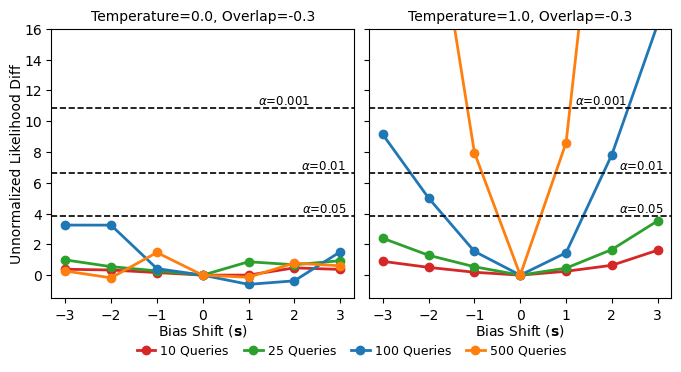

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_7254/850839728.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3)


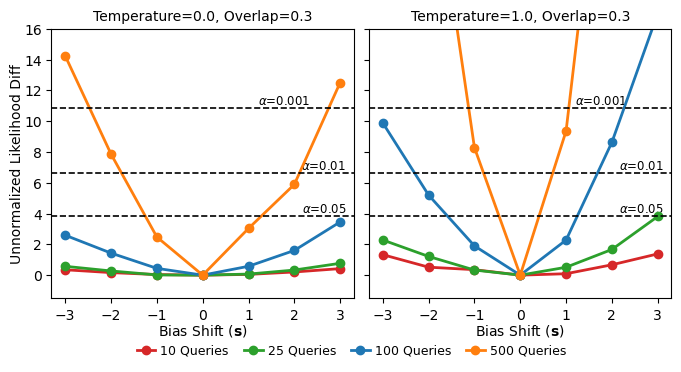

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_7254/850839728.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3)


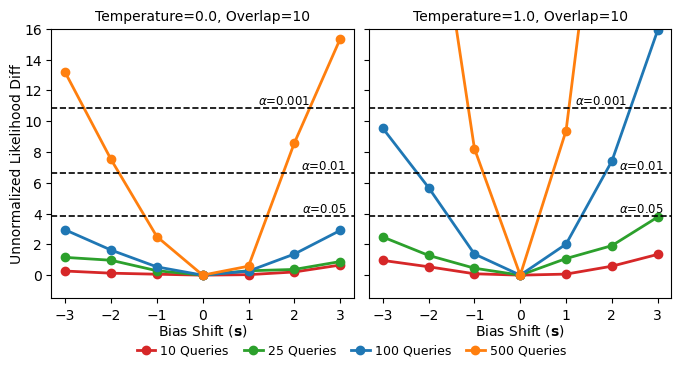

In [73]:
plot_performance_row_with_relevance(all_multi_performance_df, s_doc=-0.3, num_queries_for_sdoc=20, relevance_tower='deeper', metric='loss', diff_from_zero=True, with_comparison=True)
plot_performance_row_with_relevance(all_multi_performance_df, s_doc=0.3, num_queries_for_sdoc=10, relevance_tower='deeper', metric='loss', diff_from_zero=True, with_comparison=True)
plot_performance_row_with_relevance(all_multi_performance_df, s_doc=10, num_queries_for_sdoc=1000, relevance_tower='deeper', metric='loss', diff_from_zero=True, with_comparison=True)

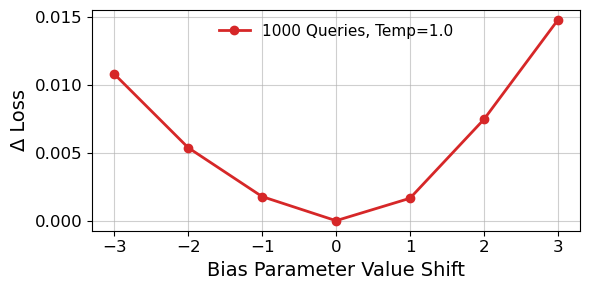

In [14]:
import matplotlib.pyplot as plt

# Parameters to plot
temperatures_to_plot = [0.0, 1.0]   # Temperatures 0.0 and 1.0
n_queries_to_plot = [1000]      # 10 and 1000 queries
s_doc_to_plot = -0.3                 # Example s_doc

fig, ax = plt.subplots(figsize=(6, 3))

# Custom markers and linestyles
markers = ['o', 's']
linestyle = '-'
colors = ['#d62728', '#1f77b4']  # Red for 10, blue for 1000 queries

# Iterate over temperatures and n_queries
for temp in temperatures_to_plot:
    for n_q, marker, color in zip(n_queries_to_plot, markers, colors):
        subset = all_multi_performance_df[
            (all_multi_performance_df['s_doc'] == s_doc_to_plot) &
            (all_multi_performance_df['policy_temperature'] == temp) &
            (all_multi_performance_df['n_queries'] == n_q)
        ].sort_values('relevance_shift')

        if subset.empty:
            continue

        # Compute difference from zero baseline
        baseline_vals = subset[subset['relevance_shift'] == 0]['loss']
        baseline = baseline_vals.mean() if not baseline_vals.empty else subset.iloc[(subset['relevance_shift'] - 0).abs().idxmin()]['loss']
        y_values = subset['loss'] - baseline

        ax.plot(
            subset['relevance_shift'],
            y_values,
            linestyle=linestyle,
            marker=marker,
            linewidth=2,
            color=color,
            label=f'{n_q} Queries, Temp={temp}'
        )

# Styling like your reference plot
ax.set_xlabel('Bias Parameter Value Shift', fontsize=14)
ax.set_ylabel('Δ Loss', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.6)

ax.legend(fontsize=11, frameon=False, ncol=2, loc='upper center')

plt.tight_layout()
plt.savefig(f"notebooks/plots/performance_sdoc_{s_doc_to_plot}_temps0_1.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()


/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_5158/342783956.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3)


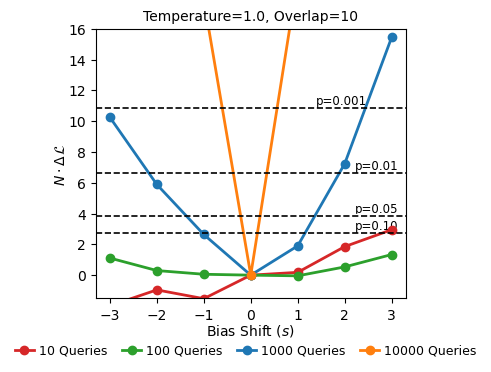

In [15]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

def plot_performance_row_with_relevance(
    df,
    s_doc,
    metric='loss',
    diff_from_zero=False,
    visualize_fn=None,  # kept for compatibility
    num_queries_for_sdoc=10,  # unused
    relevance_tower='deep',
    with_comparison=False,
):
    df = df[df['relevance_tower'] == relevance_tower]
    required_cols = {'relevance_shift', 'param_idx', 's_doc', 'policy_temperature', 'n_queries', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Missing columns: {required_cols - set(df.columns)}")

    temperatures = sorted(df['policy_temperature'].unique())
    n_queries_list = sorted(df['n_queries'].unique())
    n_cols = len(temperatures)
    fig = plt.figure(figsize=(4 * n_cols, 3.5))
    gs = gridspec.GridSpec(1, n_cols, width_ratios=[1]*n_cols, wspace=0.05, figure=fig)
    
    left_axes, all_y_values = [], []
    left_legend_handles, left_legend_labels = None, None
    first_ax = None
    
    # ✅ Custom color order: red, green, blue, orange, then fall back to tab10
    tab10 = plt.get_cmap('tab10').colors
    desired_colors = ['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']  # red, green, blue, orange
    # fill in remaining from tab10 if needed
    color_sequence = desired_colors + [c for c in tab10 if c not in desired_colors]
    color_map = {n_q: color_sequence[i % len(color_sequence)] for i, n_q in enumerate(n_queries_list)}
    
    COMPARISON_LINES = [
        (2.71, 'p=0.10'),
        (3.84, 'p=0.05'),
        (6.63, 'p=0.01'),
        (10.83, 'p=0.001')
    ]
    
    for j, temp in enumerate(temperatures):
        ax = fig.add_subplot(gs[0, j], sharey=first_ax) if first_ax else fig.add_subplot(gs[0, j])
        if first_ax is None:
            first_ax = ax
        left_axes.append(ax)
        
        subset = df[(df['s_doc'] == s_doc) & (df['policy_temperature'] == temp)]
        if subset.empty:
            ax.axis("off")
            continue

        for n_q in n_queries_list:
            sub_q = subset[subset["n_queries"] == n_q].sort_values("relevance_shift")
            if sub_q.empty:
                continue

            if diff_from_zero:
                baseline_vals = sub_q.loc[sub_q["relevance_shift"] == 0, metric]
                try:
                    baseline = baseline_vals.mean() if not baseline_vals.empty else sub_q.iloc[(sub_q["relevance_shift"] - 0).abs().idxmin()][metric]
                except Exception as e:
                    baseline = baseline_vals.mean()
                y_values = sub_q[metric] - baseline
                
                if with_comparison:
                    y_values = y_values * n_q 
                    label = f"{n_q} Queries"
                else:
                    label = f"{n_q} Queries ($\\Delta$)"
            else:
                y_values = sub_q[metric]
                label = f"{n_q} Queries"
            
            color = color_map[n_q]
            ax.plot(sub_q["relevance_shift"], y_values, marker="o", lw=2, color=color, label=label)
            all_y_values.extend(np.asarray(y_values).tolist())

        ax.set_title(f"Temperature={temp}, Overlap={s_doc}", fontsize=10)
        ax.set_xlabel("Bias Shift ($s$)")
        ax.xaxis.labelpad = 0

        if j == 0:
            y_label = f"{metric}"
            if diff_from_zero:
                y_label = f"$\\Delta$ {y_label}"
                if with_comparison:
                    y_label = f"$ N \\cdot \\Delta \\, \\mathcal{{L}}$"
                    
            ax.set_ylabel(y_label)
            ax.yaxis.labelpad = 0

        else:
            plt.setp(ax.get_yticklabels(), visible=False)

        if with_comparison and diff_from_zero:
            ax.autoscale()
            xmin, xmax = ax.get_xlim()
            for yval, label in reversed(COMPARISON_LINES):
                ax.axhline(y=yval, color="black", ls="--", lw=1.2, alpha=1, zorder=20)
                if label != "p=0.001":
                    ax.text(
                        xmax * 0.95, yval + 0.05,
                        label, color="black", fontsize=8.5, ha="right", va="bottom",
                        backgroundcolor="white", alpha=1,
                        zorder=-19
                    )
                else:
                    ax.text(
                        xmax * 0.75, yval + 0.05,
                        label, color="black", fontsize=8.5, ha="right", va="bottom",
                        backgroundcolor="white", alpha=1,
                        zorder=-19
                    )

        if left_legend_handles is None:
            h, l = ax.get_legend_handles_labels()
            if h:
                left_legend_handles, left_legend_labels = h, l

    # Adjust y-limits
    if all_y_values:
        margin = np.std(all_y_values) * 1.1 if np.std(all_y_values) > 0 else 0.1
        ymin, ymax = min(all_y_values) - margin, max(all_y_values) + margin
        if with_comparison and diff_from_zero:
            ymax = max(ymax, COMPARISON_LINES[-1][0] + 1)
        ymax = min(ymax, 16)
        ymin = max(ymin, -1.5)
        first_ax.set_ylim(ymin, ymax)
        

    # ---- Shared legend below plots -q---
    if left_legend_handles:
        fig.legend(
            left_legend_handles,
            left_legend_labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.09),
            frameon=False,
            fontsize=9,
            ncol=len(left_legend_labels),
            handlelength=1.5,
            columnspacing=1.2,
            handletextpad=0.4,
        )
    plt.tight_layout(pad=0.3)  
    plt.savefig(f"notebooks/plots/performance_relevance_sdoc_{s_doc}.pdf", dpi=300, bbox_inches='tight',   # 🔥 ensures legend + labels fully included
    pad_inches=0.05  )
    plt.show()
plot_performance_row_with_relevance(all_multi_performance_df, s_doc=10, num_queries_for_sdoc=1000, relevance_tower='deeper', metric='loss', diff_from_zero=True, with_comparison=True)

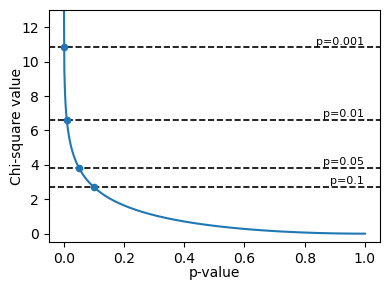

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# choose degrees of freedom
df = 1

# p-values from 0 to 1 (but avoid exactly 0)
p = np.linspace(0.0001, 0.9999, 500)
chi_vals = chi2.ppf(1 - p, df)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(p, chi_vals)

# special p-values
special_p = np.array([0.01, 0.05, 0.10, 0.001])
special_chi = chi2.ppf(1 - special_p, df)

# --- draw horizontal red dashed lines instead of dots ---
COMPARISON_LINES = list(zip(special_chi, [f"p={p}" for p in special_p]))

xmin, xmax = ax.get_xlim()

for yval, label in COMPARISON_LINES:
    ax.axhline(y=yval, color="black", ls="--", lw=1.2, alpha=1)
    ax.text(
        xmax * 0.95, yval + 0.05,
        label, color="black", fontsize=8, ha="right", va="bottom",
        backgroundcolor="white", alpha=1,
        zorder=-10
    )
special_p = np.array([0.01, 0.05, 0.10, 0.001])
special_chi = chi2.ppf(1 - special_p, df)

plt.scatter(special_p, special_chi, s=20, zorder=5)
ax.set_ylim(-0.5, 13)
# labels
ax.set_xlabel("p-value")
ax.xaxis.labelpad = 0
ax.set_ylabel("Chi-square value")
ax.yaxis.labelpad = -2
plt.tight_layout()
plt.savefig("notebooks/plots/chi_square_p_values.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_relevance_single(
    s_doc,
    num_queries,
    docs_per_group=10,
    hidden_units=[32, 32, 32],
    noise=0.0,
    random_state=41,
    seed=42,
    baseline_gap=0.25,
    cap_height=0.15,
    jitter=0.05,
    fill_cmap="tab10",
    point_cmap="tab10",
    figsize=(6, 4),
    show_legend=True,
):
    """
    Produce a single relevance visualization plot.
    Handles model scoring, fill spans, caps, and scatter points.
    """

    fig, ax = plt.subplots(figsize=figsize)

    rng = np.random.default_rng(seed)
    cmap_fill = plt.get_cmap(fill_cmap)
    cmap_point = plt.get_cmap(point_cmap)

    global_ymin = np.inf
    global_ymax = -np.inf

    # ------------------------------------------------------------------
    # 1. Generate data using the provided model + scoring functions
    # ------------------------------------------------------------------
    deep_relevance = DeepRelevance(hidden_units=hidden_units,
                                   random_state=random_state,
                                   noise=noise)

    scores, data, boundaries = generate_deep_score_and_features_overlap(
        num_queries=num_queries,
        docs_per_group=docs_per_group,
        s_doc=s_doc,
        rng=rng,
        deep_model=deep_relevance,
    )

    doc_ids = np.array([d[1] for d in data])
    b_values = np.array([d[2][1] for d in data])

    # ------------------------------------------------------------------
    # 2. Model curve
    # ------------------------------------------------------------------
    b_plot = np.linspace(0, 10, 500)
    a_plot = np.zeros_like(b_plot)
    X_plot = np.column_stack((a_plot, b_plot))
    y_plot = np.ravel(deep_relevance(X_plot))

    ax.plot(b_plot, y_plot, color='black', lw=2, label="Model curve")

    global_ymin = min(global_ymin, np.min(y_plot))
    global_ymax = max(global_ymax, np.max(y_plot))

    # ------------------------------------------------------------------
    # 3. Mean boundaries for fill + caps
    # ------------------------------------------------------------------
    mean_bounds = []
    for doc_idx in range(docs_per_group):
        lefts = [q_bounds[doc_idx][0] for q_bounds in boundaries]
        rights = [q_bounds[doc_idx][1] for q_bounds in boundaries]
        mean_bounds.append((np.mean(lefts), np.mean(rights)))

    fill_colors = [cmap_fill(i / max(1, docs_per_group - 1)) for i in range(docs_per_group)]
    point_colors = [cmap_point(i / max(1, docs_per_group - 1)) for i in range(docs_per_group)]

    fill_alpha = 0.25 if s_doc != 10 else 0.10

    for i, (l, r) in enumerate(mean_bounds):
        color = fill_colors[i]

        ax.axvspan(l, r, color=color, alpha=fill_alpha)

        baseline_y = -baseline_gap * i - 1
        ax.hlines(y=baseline_y, xmin=l + 0.05, xmax=r - 0.05,
                  color=color, lw=3, alpha=0.9)
        ax.vlines([l + 0.05, r - 0.05],
                  baseline_y - cap_height,
                  baseline_y + cap_height,
                  color=color, lw=2)

        global_ymin = min(global_ymin, baseline_y - cap_height)
        global_ymax = max(global_ymax, baseline_y + cap_height)

        ax.axvline(x=l, color=color, ls='--', lw=1.3, alpha=0.8)
        ax.axvline(x=r, color=color, ls='--', lw=1.3, alpha=0.8)

    # ------------------------------------------------------------------
    # 4. Scatter points
    # ------------------------------------------------------------------
    y_jittered = scores + rng.normal(0, jitter, size=scores.shape)
    points = np.column_stack((b_values, y_jittered, doc_ids))
    rng.shuffle(points)

    x_s = points[:, 0]
    y_s = points[:, 1]
    d_s = points[:, 2].astype(int)

    colors = [point_colors[i % len(point_colors)] for i in d_s]

    ax.scatter(
        x_s, y_s,
        c=colors,
        s=60,
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

    global_ymin = min(global_ymin, np.min(y_s))
    global_ymax = max(global_ymax, np.max(y_s))

    # ------------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------------
    ax.set_xlim(0, 10)
    ax.set_ylim(global_ymin, global_ymax + 0.2)
    ax.set_xlabel("Feature value")
    ax.xaxis.labelpad = 0
    ax.set_ylabel("Relevance Logit")
    ax.yaxis.labelpad = -5

    # Legend
    if show_legend:
        legend_handles = []
        legend_labels = []

        for i in range(docs_per_group):
            color = plt.get_cmap(point_cmap)(i / max(1, docs_per_group - 1))
            h = plt.Line2D([], [], color=color, marker='o', markersize=8,
                           markeredgecolor='black', linestyle='None')
            legend_handles.append(h)
            legend_labels.append(f"Rank {i}")

        curve_handle = plt.Line2D([], [], color='black', lw=2)
        legend_handles.append(curve_handle)
        legend_labels.append("True function")

    fig.legend(
        legend_handles,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.08),
        ncol=6,
        frameon=False,
        fontsize=9,
        labelspacing=0.4,     # vertical spacing between rows
        handletextpad=0.3,    # space between marker and text
        columnspacing=0.7     # horizontal spacing between columns
    )

    plt.tight_layout()
    plt.savefig(f"notebooks/plots/relevance_single_plot_s_doc_{s_doc}_num_queries_{num_queries}.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.show()


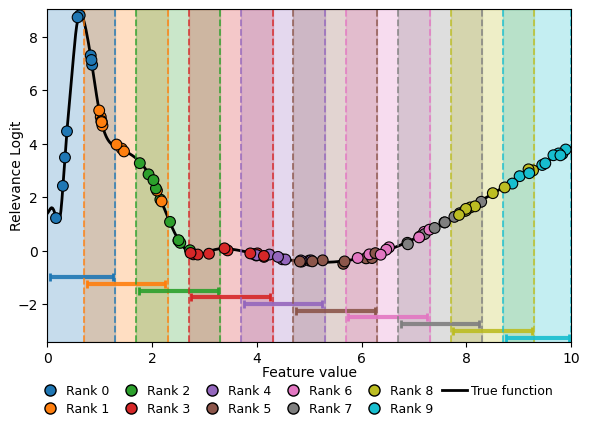

In [21]:
plot_relevance_single(s_doc=0.3,num_queries=10, seed=107)

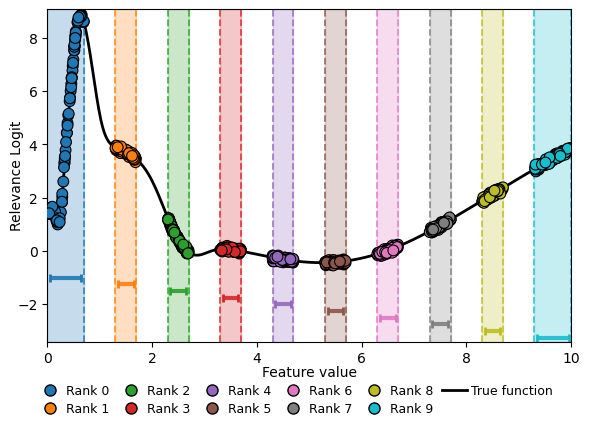

In [22]:
plot_relevance_single(s_doc=-0.3,num_queries=100)